# Water-use data available from USGS

The U.S. Geological Survey maintains national data bases of water-use information. The data are collected and compiled every five years for each State, the District of Columbia, Puerto Rico, and the U.S. Virgin Islands. County, State, and national water-use estimates may be downloaded from the National Water Information System Web (NWISWeb) interface, [**Water Data for the Nation**](http://waterdata.usgs.gov/), by selecting the Water Use button or data category pull-down. Data on NWISWeb represent the current best estimates, and may have been revised from previous publications. Data available from the links below generally reflect the published report, and may have been revised in subsequent analyses.

**Note: State-level data from 1950-1980 and watershed data are not available on NWISWeb.**

Other files, such as lists of county names, graphics, and charts, are also available for some years.

* [Download 2015 publication data for counties](https://water.usgs.gov/watuse/data/data2015.html)
* [Download 2010 publication data for counties](https://water.usgs.gov/watuse/data/2010/index.html)
* [Download 2005 publication data for counties](https://water.usgs.gov/watuse/data/2005/index.html)
* [Download 2000 publication data for counties](https://water.usgs.gov/watuse/data/2000/index.html)
* [Download 2000 publication data for principal aquifers](https://water.usgs.gov/watuse/data/2000/aquifer.html)
* [Download 1995 publication data for counties and watersheds](https://water.usgs.gov/watuse/data/1995/index.html)
* [Download 1990 publication data for counties and watersheds](https://water.usgs.gov/watuse/data/1990/index.html)
* [Download 1985 publication data for counties and watersheds](https://water.usgs.gov/watuse/data/1985/index.html)
* [Download 1950-1980 publication data for States](https://www.sciencebase.gov/catalog/item/584f00cee4b0260a373819db)


In [1]:
%run /scratch/hdagne1/LivestockWaterUse/scripts/extract_usgs_livestock.py

Fetching USGS sources:   0%|          | 0/8 [00:00<?, ?file/s]

State-Level  1960-1980:   0%|          | 0/5 [00:00<?, ?yr/s]

County-Level 1985-2015:   0%|          | 0/7 [00:00<?, ?yr/s]

Done.
  state-level     245 rows x  9 cols  (1960-1980)  ->  usgs_livestock_state_1960_1980.feather
  county-level 21,768 rows x 10 cols  (1985-2015)  ->  usgs_livestock_county_1985_2015.feather
  scope     conus
  tables    /scratch/hdagne1/LivestockWaterUse/data/usgs_ls_state_county_1960_2015
  NOTE: 2 rows have no county name (retired FIPS codes; see the QA report)


## USDA NASS Census Data

The U.S. Department of Agriculture (USDA), National Agricultural Statistics Service (NASS), provides large agricultural datasets through its **Datasets** portal. Download agricultural statistics large datasets using .gz files. Zip Files, like .gz files, are compressed, or zipped, to save storage space and/or to bundle several files together. The files are unzipped in Linux, Windows or Mac environments. Even though you can see what is in the .gz file, you must unzip the file before you can open the individual files in the archive. Programmers, analysts, and researchers commonly use .gz files to import large datasets into their preferred software for further analysis.

### Census Data

* **qs.census2002.txt.gz**
* **qs.census2007.txt.gz**
* **qs.census2012.txt.gz**
* **qs.census2017.txt.gz**
* **qs.census2022.txt.gz**

**Source:** [USDA NASS — Datasets](https://www.nass.usda.gov/datasets/?utm_source=chatgpt.com)


In [2]:
%run /scratch/hdagne1/LivestockWaterUse/scripts/usda_livestock.py

Fetching NASS census:   0%|          | 0/5 [00:00<?, ?file/s]

Parsing census years:   0%|          | 0/5 [00:00<?, ?yr/s]

Done.
  combined     52,826 rows x 7 cols  (2002-2022, 4 types, 3,062 counties)
  dairy_cattle  11,516 rows  (2,963 counties)  ->  usda_dairy_cattle_county_2002_2022.feather
  beef_cattle  15,091 rows  (3,050 counties)  ->  usda_beef_cattle_county_2002_2022.feather
  poultry      14,313 rows  (3,042 counties)  ->  usda_poultry_county_2002_2022.feather
  hogs         11,906 rows  (2,917 counties)  ->  usda_hogs_county_2002_2022.feather
  scope      conus
  tables     /scratch/hdagne1/LivestockWaterUse/data/usda_census


# ERA5-Land climate data for CONUS counties and states (1960–2022).
"""
Outputs
-------
- era5_county_1960_2022.feather       County-level annual climate
- era5_state_1960_2022.feather        State-level annual climate
- era5_county_ratios_1960_2022.feather County/state predictors

Notes
-----
- Temperature ratios use Kelvin; temperature differences use °C.
- Relative humidity is calculated monthly, then averaged annually.
- County IDs use 5-digit FIPS (GEOID), not names.
- CONUS filtering and small-county fallback are handled before/within reduction.
- Annual results are cached to allow interrupted runs to resume.
- TIGER 2018 boundaries are applied to all years; historical boundary changes
  therefore introduce approximation in earlier county-level estimates.

Usage
-----
python era5_climate.py --project my-ee-project
python era5_climate.py --project my-ee-project --start 1985 --end 2022

from era5_climate import run
county, state, ratios = run(project="my-ee-project")
"""

In [75]:
%run /scratch/hdagne1/LivestockWaterUse/scripts/era5_climate_GEE.py

ERA5 county:   0%|          | 0/63 [00:00<?, ?yr/s]

/scratch/hdagne1/LivestockWaterUse/scripts/era5_climate_GEE.py:302: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  frames.append(df)
/scratch/hdagne1/LivestockWaterUse/scripts/era5_climate_GEE.py:302: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  frames.append(df)
/scratch/hdagne1/LivestockWaterUse/scripts/era5_climate_GEE.py:302: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA colu

RuntimeError: Earth Engine call failed after 5 tries: ('invalid_grant: Token has been expired or revoked.', {'error': 'invalid_grant', 'error_description': 'Token has been expired or revoked.'})

# USGS Livestock Water use

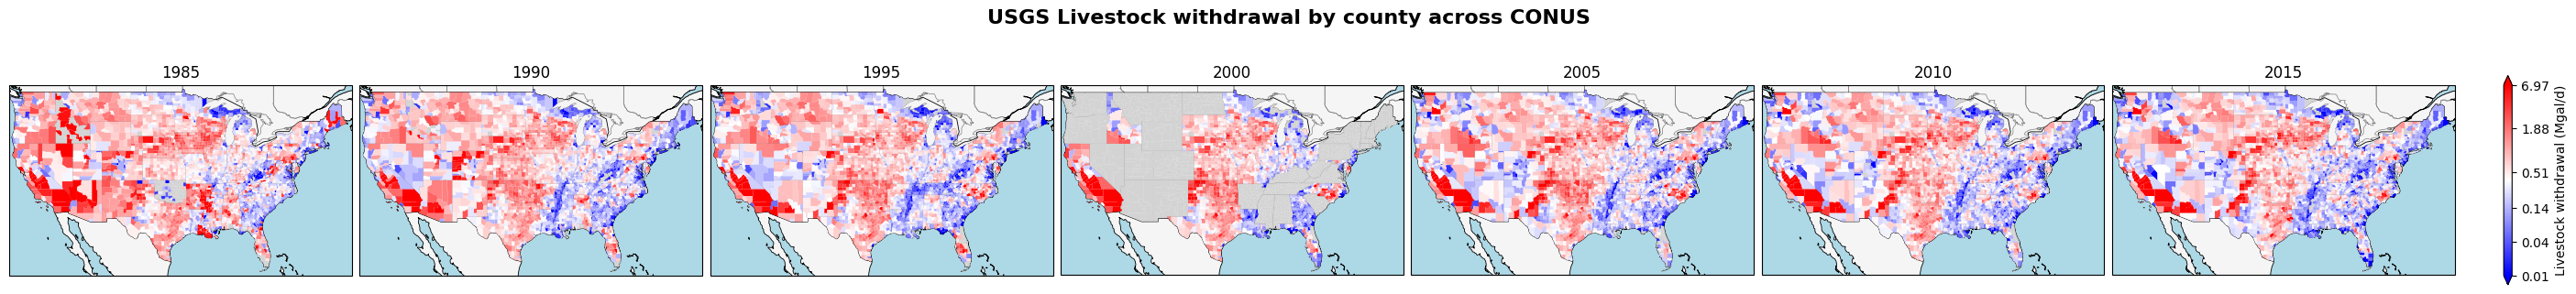

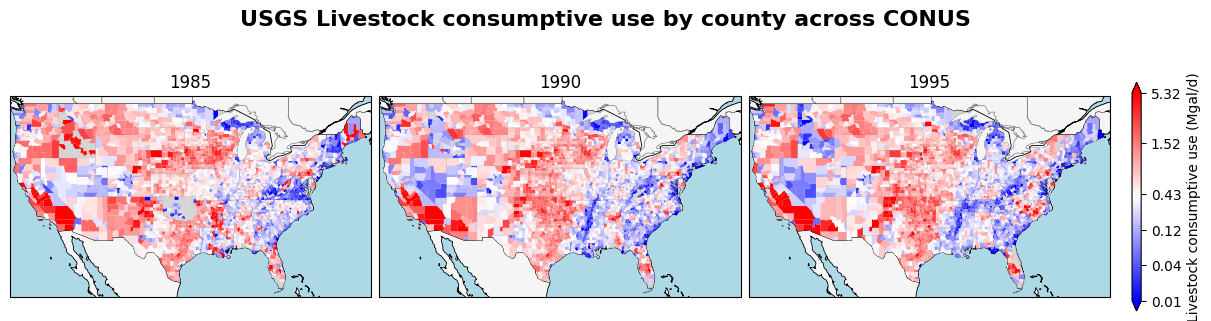

In [30]:
%run /scratch/hdagne1/LivestockWaterUse/figures/usgs_livestock_wateruse_plot.py

# County maps of livestock inventory, 2002–2022

One figure per livestock type, five panels (census years) sharing a singlelog colour scale so the years are directly comparable. Grey counties have no reported value: NASS suppresses counts that would
identify an individual operation, so these are unknown, not zero.

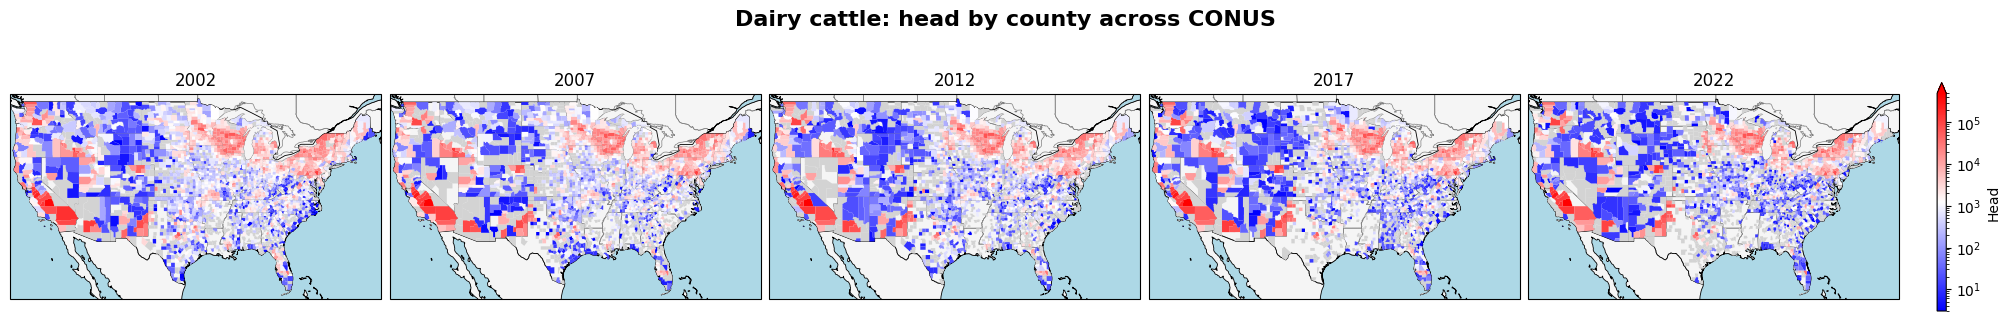

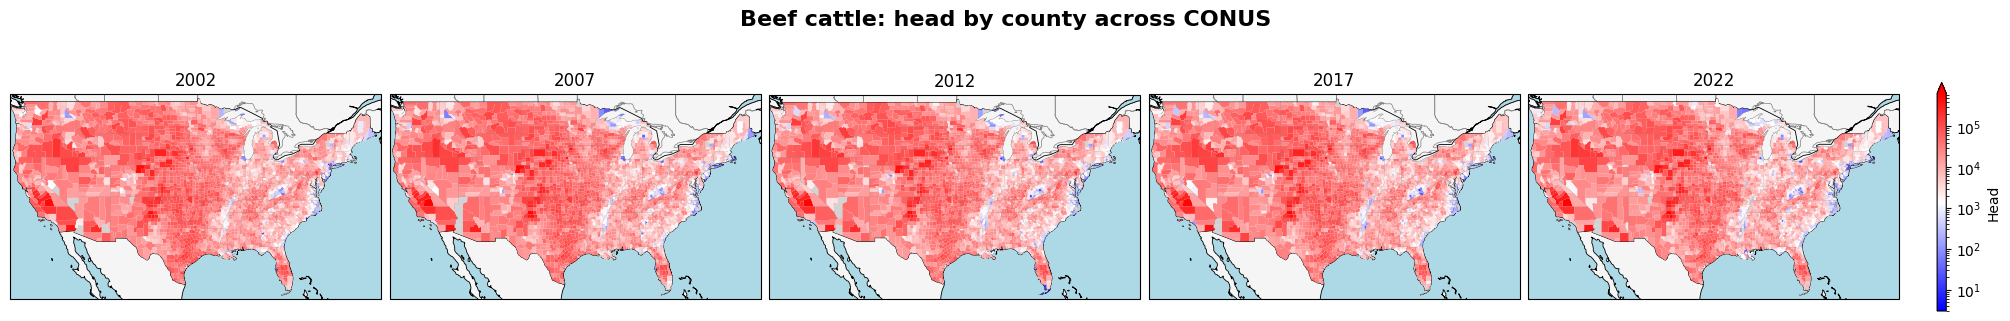

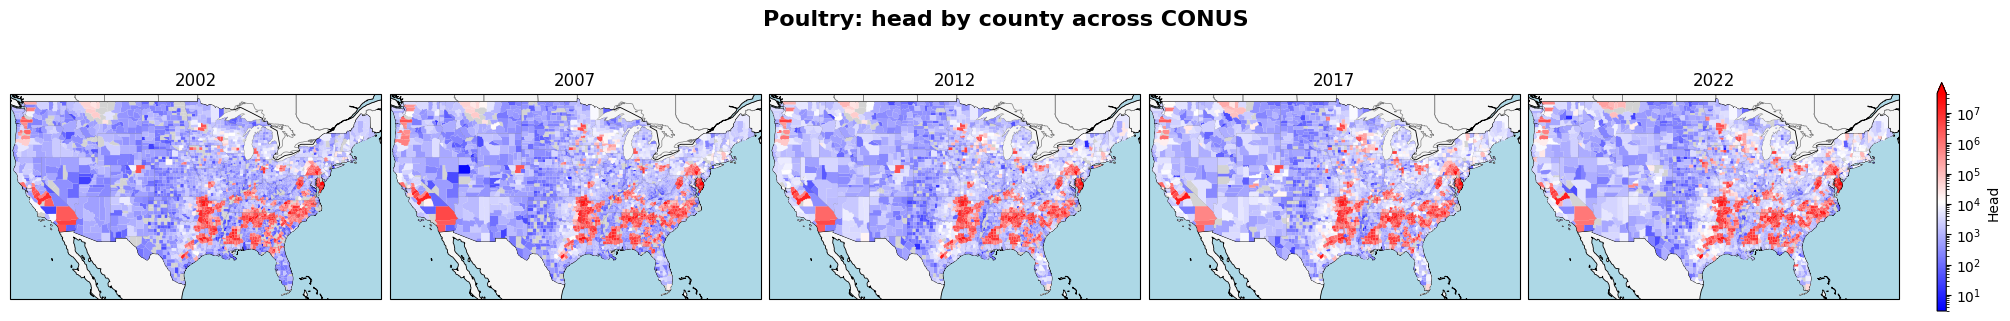

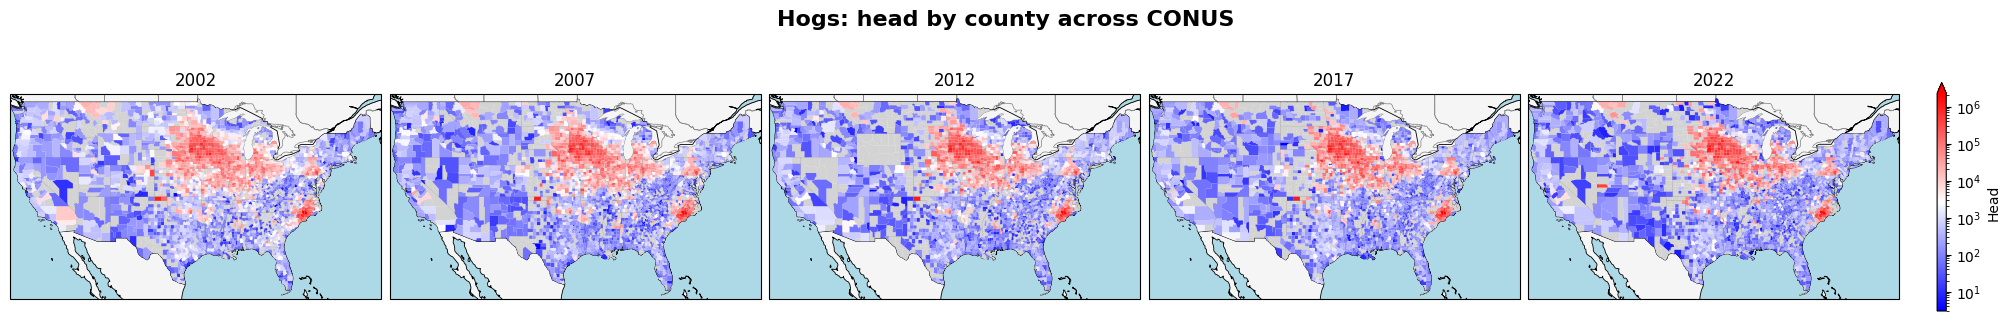

In [31]:
%run /scratch/hdagne1/LivestockWaterUse/figures/usda_census_plot.py

In [55]:
%run /scratch/hdagne1/LivestockWaterUse/scripts/wcc_mlr.py

Generating WCC samples:   0%|          | 0/4 [00:00<?, ?type/s]

Fitting MLR surrogates:   0%|          | 0/4 [00:00<?, ?type/s]

Generating surrogate WCC:   0%|          | 0/4 [00:00<?, ?type/s]

Done.
  dairy_cattle    50,000 samples  R2 test 0.7583  RMSPE   8.3%
  beef_cattle     50,000 samples  R2 test 0.9587  RMSPE   7.7%
  hogs            50,000 samples  R2 test 0.9246  RMSPE   8.3%
  poultry         50,000 samples  R2 test 0.9047  RMSPE   7.2%
  files      wcc_samples_<type>.feather      literature WCC + surrogate
             wcc_surrogate_<type>.feather    independent draw, surrogate WCC
             wcc_mlr_surrogate_all.feather   wide, one column pair per type
             wcc_mlr_coefficients.feather / wcc_mlr_equations.feather
  basis      drinking
  tables     /scratch/hdagne1/LivestockWaterUse/data/wcc_mlr


# MLR fitting:

  Dairy cattle   n= 50,000  slope=0.7669  intercept=5.51  R2=0.7652  RMSE=1.70  R2(1:1)=0.7652
  Beef cattle    n= 50,000  slope=0.9540  intercept=0.501  R2=0.9553  RMSE=0.863  R2(1:1)=0.9553
  Hogs           n= 50,000  slope=0.9183  intercept=0.154  R2=0.9223  RMSE=0.154  R2(1:1)=0.9223
  Poultry        n= 50,000  slope=0.9029  intercept=3.93e-03  R2=0.9069  RMSE=2.84e-03  R2(1:1)=0.9069


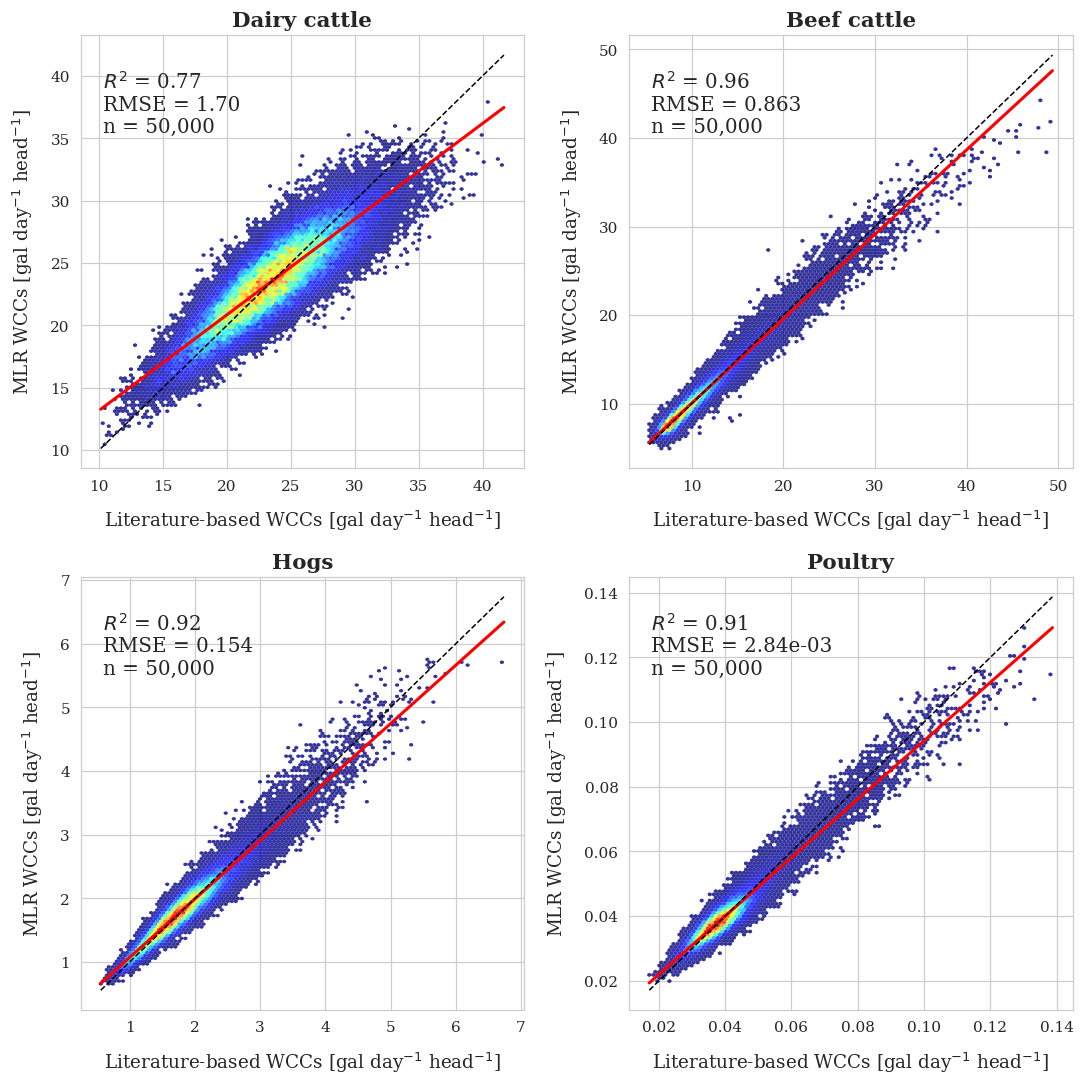

In [72]:
%run /scratch/hdagne1/LivestockWaterUse/figures/mlr_plot.py

In [73]:
%run /scratch/hdagne1/LivestockWaterUse/scripts/era5_climate_GEE.py

/bighome/hdagne1/.conda/envs/BUDYKO-dev/lib/python3.10/site-packages/google/api_core/_python_version_support.py:273: FutureWarning: You are using a Python version (3.10.20) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


ERA5 county:   0%|          | 0/63 [00:00<?, ?yr/s]

/scratch/hdagne1/LivestockWaterUse/scripts/era5_climate_GEE.py:297: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = (pd.concat([df.loc[~missing], fix], ignore_index=True)
/scratch/hdagne1/LivestockWaterUse/scripts/era5_climate_GEE.py:297: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = (pd.concat([df.loc[~missing], fix], ignore_index=True)
/scratch/hdagne1/LivestockWaterUse/scripts/era5_climate_GEE.py:297: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries 

KeyboardInterrupt: 

In [74]:
pd.read_feather("/scratch/hdagne1/LivestockWaterUse/data/_cache/era5/county_1960.feather")

,NAME,area_m2,dewpoint_k,fips,precip_m,rh_pct,state_fips,temp_k,year
0,St. Louis,1.709952e+08,279.199760,29510,0.676017,64.491703,29,285.834421,1960
1,Carson City,4.069164e+08,271.979838,32510,0.482687,54.768102,32,281.770465,1960
2,Covington,1.467865e+07,277.605581,51580,0.920773,69.058411,51,283.018716,1960
3,Buena Vista,1.688544e+07,278.244514,51530,0.869438,66.987394,51,284.151911,1960
4,Lexington,6.538920e+06,278.150381,51678,0.867091,67.239908,51,283.995839,1960
...,...,...,...,...,...,...,...,...,...
3121,Middlesex,1.135572e+09,277.830895,09007,1.219389,71.096545,09,282.800817,1960
3122,Tolland,1.078746e+09,276.799418,09013,1.125921,70.168758,09,281.937401,1960
3123,Hartford,1.941216e+09,277.064277,09003,1.189235,71.181000,09,281.995681,1960
3124,New London,1.996573e+09,277.767800,09011,1.189771,70.994613,09,282.756573,1960
